# K-Means RFM Customer Segmentation using Online Retail Transaction Data

###Jade Webb

###Mar 2026

###Dataset: https://archive.ics.uci.edu/dataset/352/online+retail

## Installations, Imports, and Constants

In [1]:
pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from scipy import stats
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from ucimlrepo import fetch_ucirepo
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

In [3]:
RANDOM_STATE = 42
TITLE_FONT_SIZE = 17
LABEL_TICK_FONT_SIZE = 15
CMAP_1 = sns.color_palette()[0]
CMAP_4 = ListedColormap([sns.color_palette()[0], sns.color_palette()[1], sns.color_palette()[2], sns.color_palette()[4]])
CMAP_5 = ListedColormap([sns.color_palette()[0], sns.color_palette()[1], sns.color_palette()[2], sns.color_palette()[4], sns.color_palette()[6]])
CMAP_5_PROFILES = ListedColormap([sns.color_palette()[4], sns.color_palette()[2], sns.color_palette()[6], sns.color_palette()[0], sns.color_palette()[1]])

##Load, Inspect, and Clean Online Retail Transaction Dataset

In [4]:
online_retail = fetch_ucirepo(id=352)
df_ids = online_retail.data.ids
df_features = online_retail.data.features

In [5]:
#merge dataset ids and features
df = df_ids.merge(df_features, left_index=True, right_index=True)

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


###Null

In [8]:
df = df.dropna(axis=0)

###Duplicates

In [9]:
df.duplicated().sum()

np.int64(5225)

In [10]:
df = df.drop_duplicates()

###Format

In [11]:
#convert InvoiceDate datatype to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(df["InvoiceDate"].dtype)

datetime64[ns]


###Impossible Values

In [12]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,401604.000000,401604.000000
mean,12.183273,3.474064
std,250.283037,69.764035
min,-80995.000000,0.000000
25%,2.000000,1.250000
50%,5.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,38970.000000


In [13]:
#quantity must be positive and unit price must be at least 0.01
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] >= 0.01)]

In [14]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,392688.000000,392688.000000
mean,13.119825,3.125946
std,180.493747,22.241947
min,1.000000,0.040000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


###Feature Extraction

In [15]:
#calcuate total spent
df["Total"] = df['Quantity'] * df['UnitPrice']

In [16]:
df[["Quantity", "UnitPrice", "Total"]].describe()

,Quantity,UnitPrice,Total
count,392688.000000,392688.000000,392688.00000
mean,13.119825,3.125946,22.63173
std,180.493747,22.241947,311.10080
min,1.000000,0.040000,0.06000
25%,2.000000,1.250000,4.95000
50%,6.000000,1.950000,12.45000
75%,12.000000,3.750000,19.80000
max,80995.000000,8142.750000,168469.60000


###Outliers

Clip outliers using a quantile-based upper threshold until &lt;2.0 skewness is achieved for all numeric features (Quantity, UnitPrice, Total)

In [17]:
#sturges' rule for optimal histogram bins
optimal_bins = math.ceil(math.log2(len(df)) + 1)

In [18]:
#plots a histogram for a given feature
#title indicates clip threshold (if clip < 1) and skewness
def single_histogram(df, clip, feature, axes):
  sns.histplot(df[feature], bins=optimal_bins, kde=True, ax=axes)
  skewness = "{:.2f}".format(skew(df[feature]))
  if (clip < "1"):
      axes.set_title('Distribution of ' + feature + ' After Outlier Clipping\nClip Threshold = ' + clip + ', Skewness = ' + skewness, fontsize = TITLE_FONT_SIZE)
  else:
      axes.set_title('Distribution of ' + feature + ' Before Outlier Clipping\nSkewness = ' + skewness, fontsize = TITLE_FONT_SIZE)
  axes.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE)
  axes.set_xlabel(feature, fontsize=LABEL_TICK_FONT_SIZE)
  axes.set_ylabel("Count", fontsize=LABEL_TICK_FONT_SIZE)

In [19]:
#plots histograms for Quantity, UnitPrice, and Total features, for a given clip threshold
def plot_histogram(df, clip):
  fig, axes = plt.subplots(1, 3, figsize=(24, 6))

  single_histogram(df, clip, "Quantity", axes[0])
  single_histogram(df, clip, "UnitPrice", axes[1])
  single_histogram(df, clip, "Total", axes[2])

  plt.tight_layout()
  plt.show()

In [20]:
#clips outliers of Quantity, UnitPrice, and Total features at a given quantile-based upper threshold
def clip_outliers(clip_upper_threshold):
  quantity_quantile = df['Quantity'].quantile(clip_upper_threshold)
  unitprice_quantile = df['UnitPrice'].quantile(clip_upper_threshold)
  total_quantile = df['Total'].quantile(clip_upper_threshold)
  df_clipped = df.copy()
  df_clipped['Quantity'] = df['Quantity'].clip(upper=quantity_quantile)
  df_clipped['UnitPrice'] = df['UnitPrice'].clip(upper=unitprice_quantile)
  df_clipped['Total'] = df['Total'].clip(upper=total_quantile)
  return df_clipped

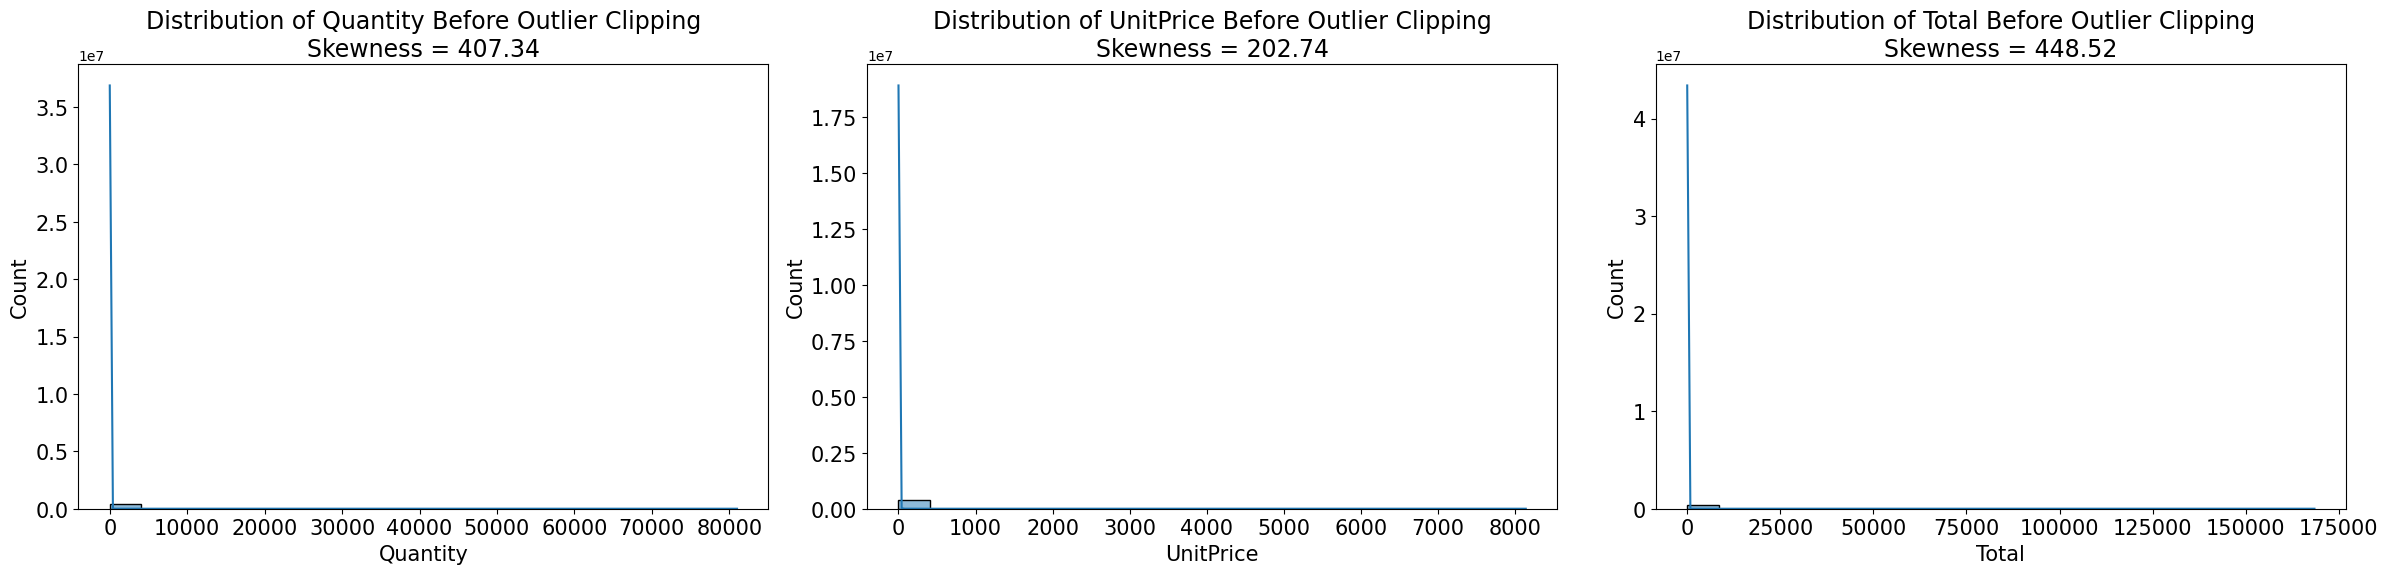

In [21]:
plot_histogram(df, "1")

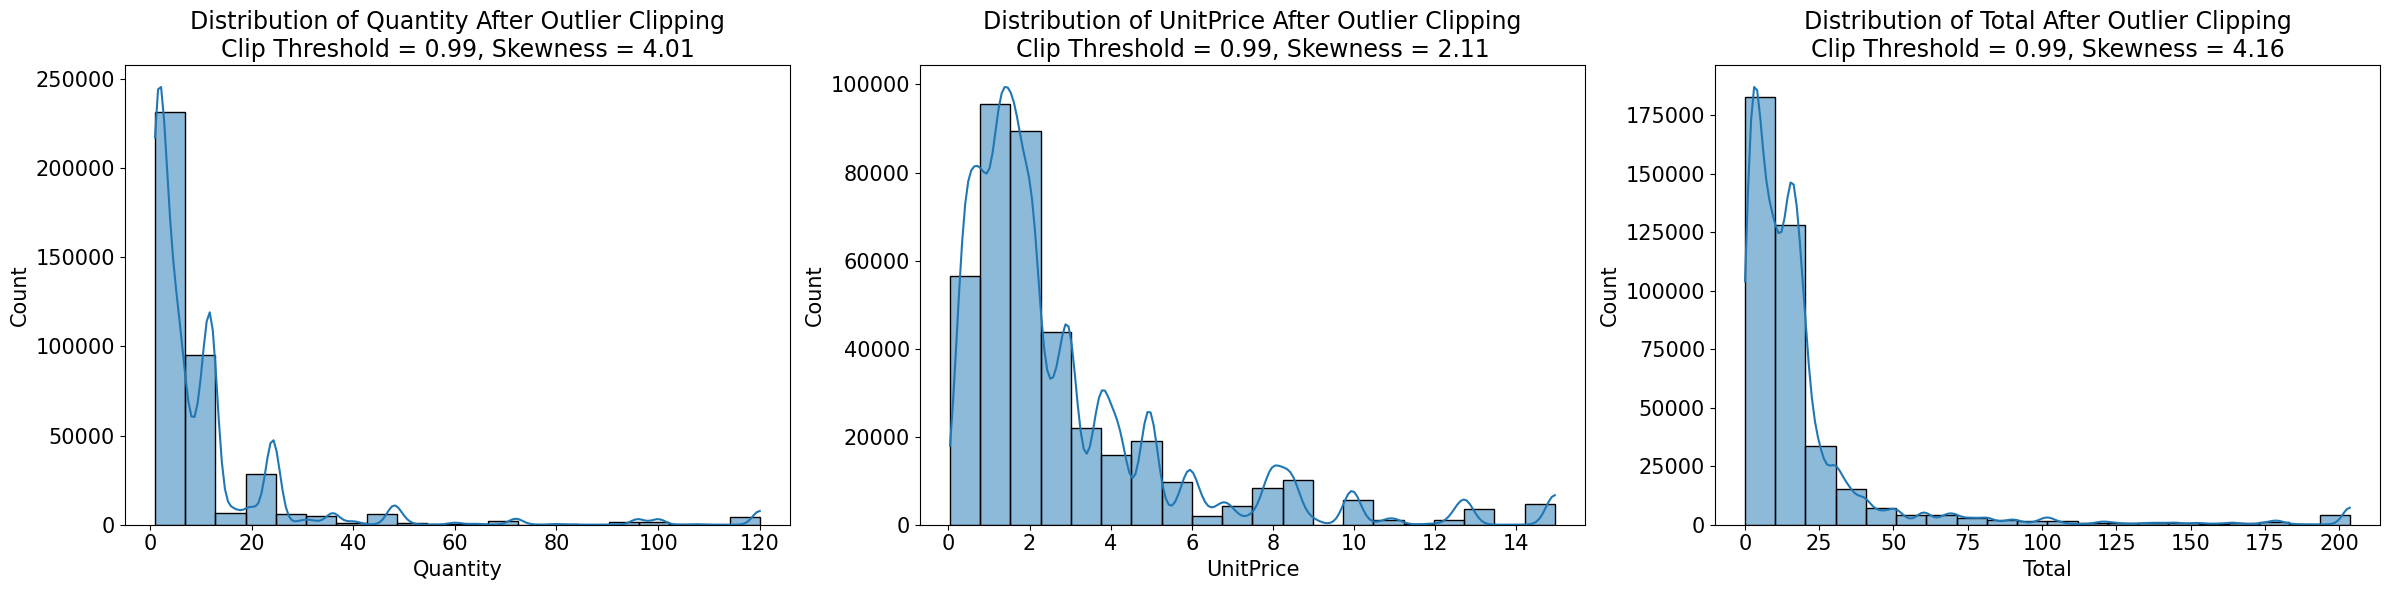

In [22]:
df_clipped = clip_outliers(0.99)
plot_histogram(df_clipped, "0.99")

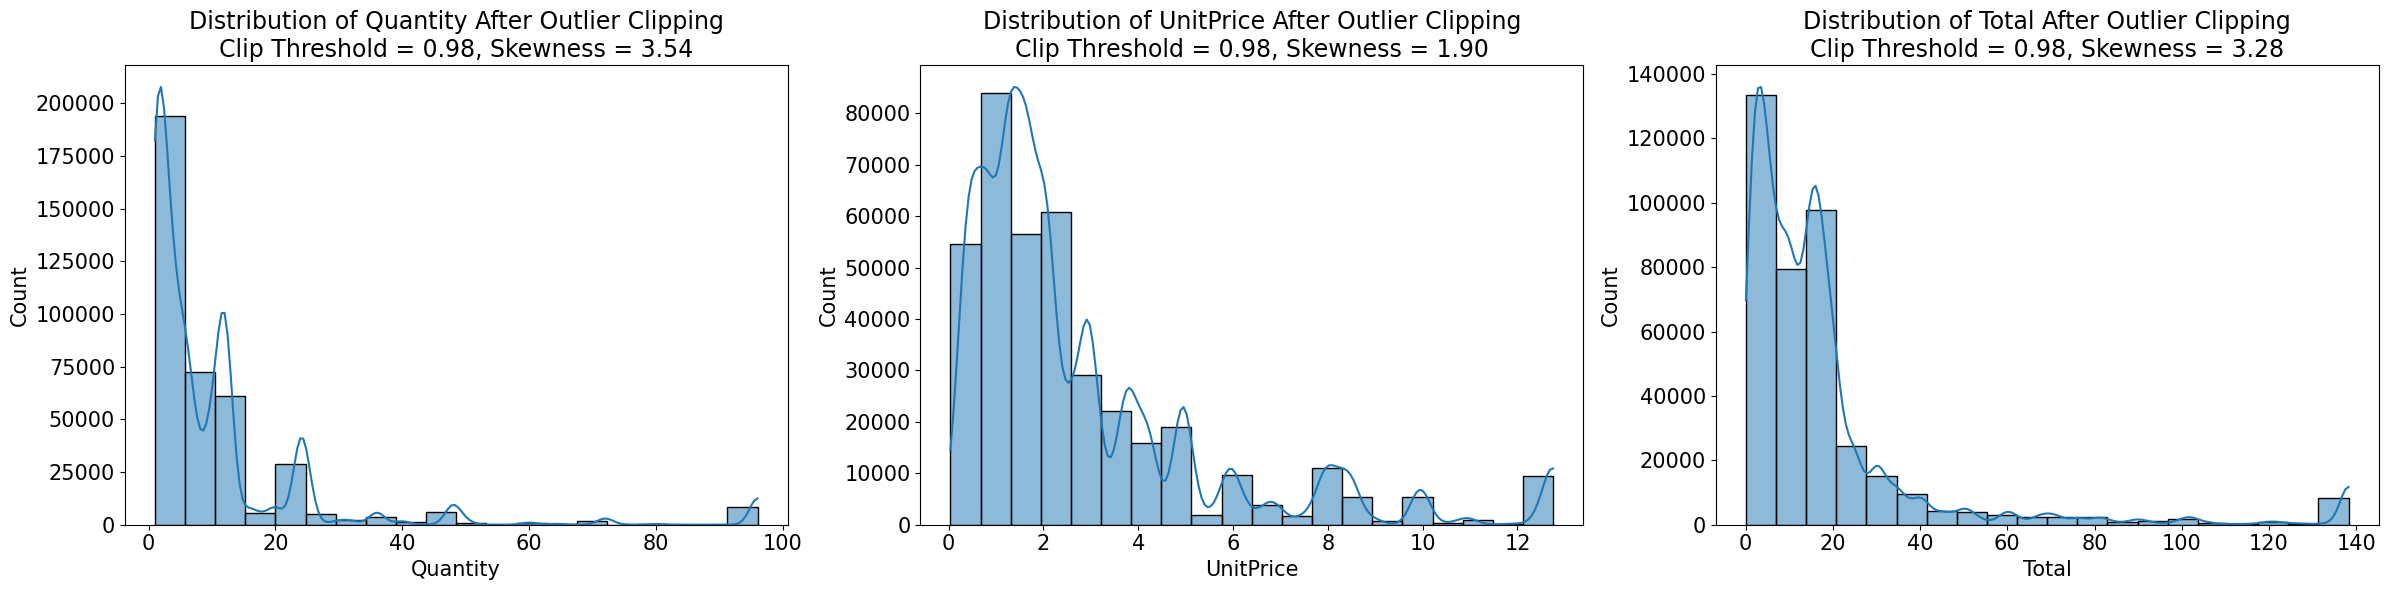

In [23]:
df_clipped = clip_outliers(0.98)
plot_histogram(df_clipped, "0.98")

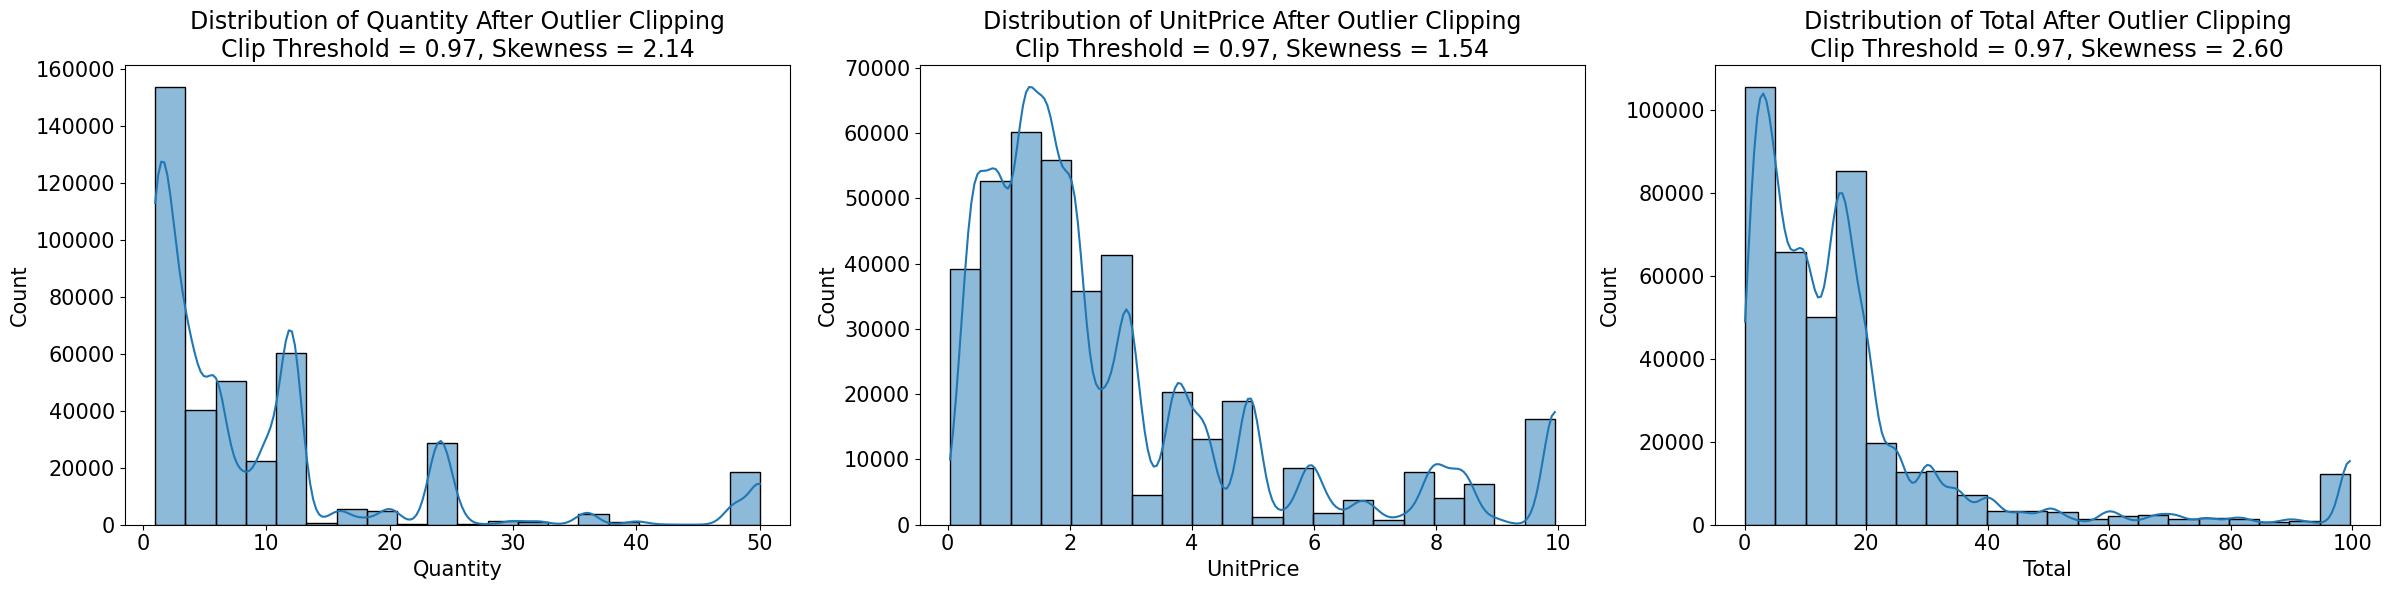

In [24]:
df_clipped = clip_outliers(0.97)
plot_histogram(df_clipped, "0.97")

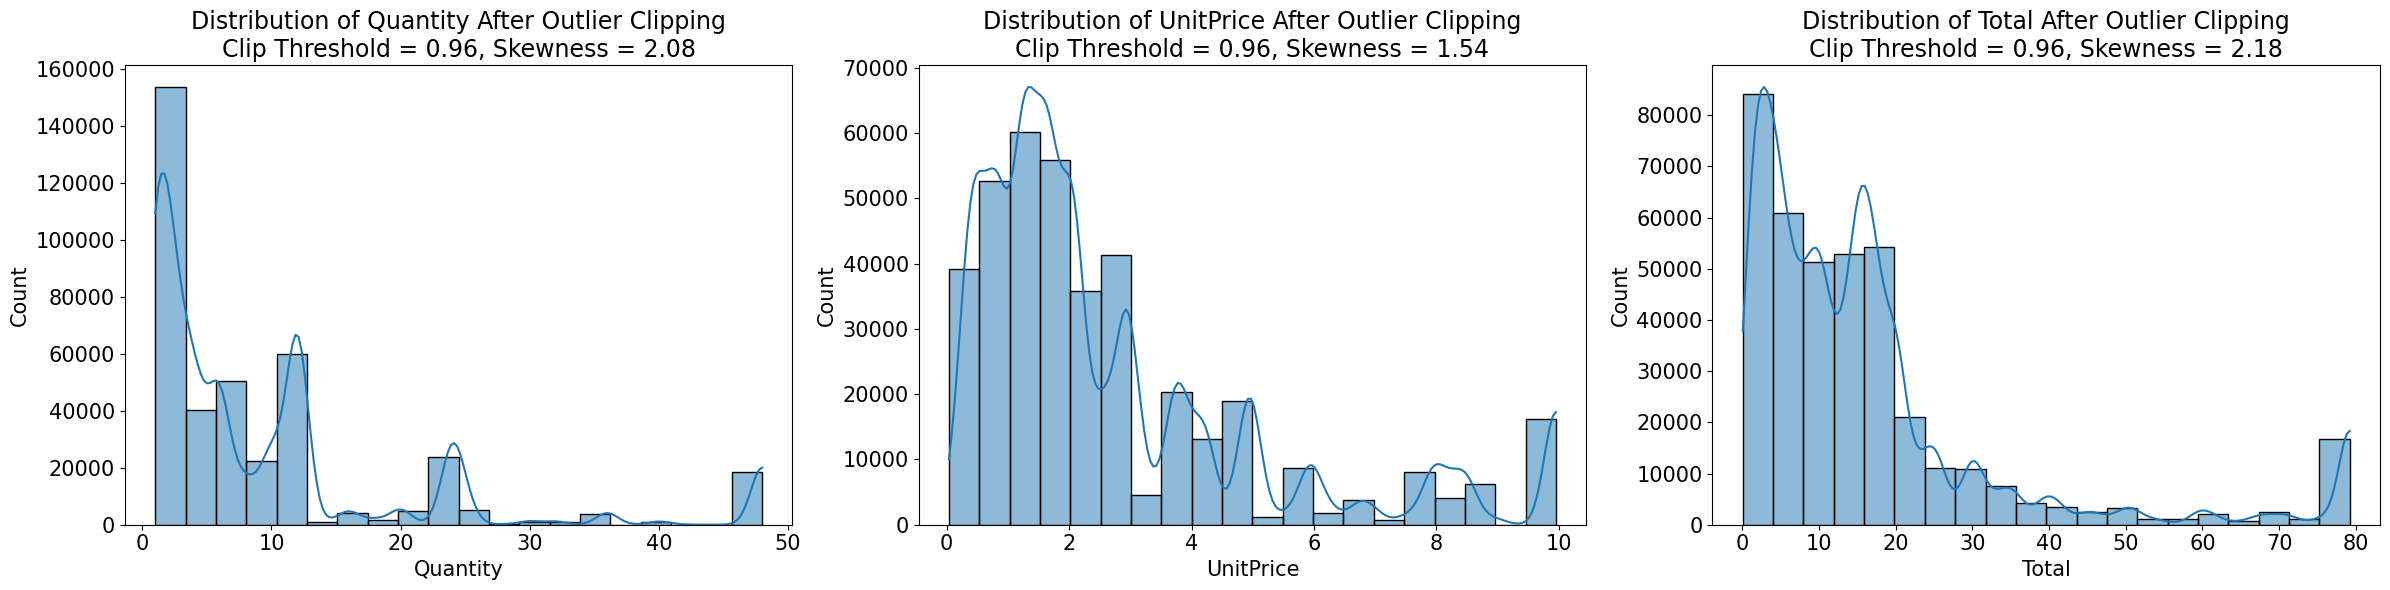

In [25]:
df_clipped = clip_outliers(0.96)
plot_histogram(df_clipped, "0.96")

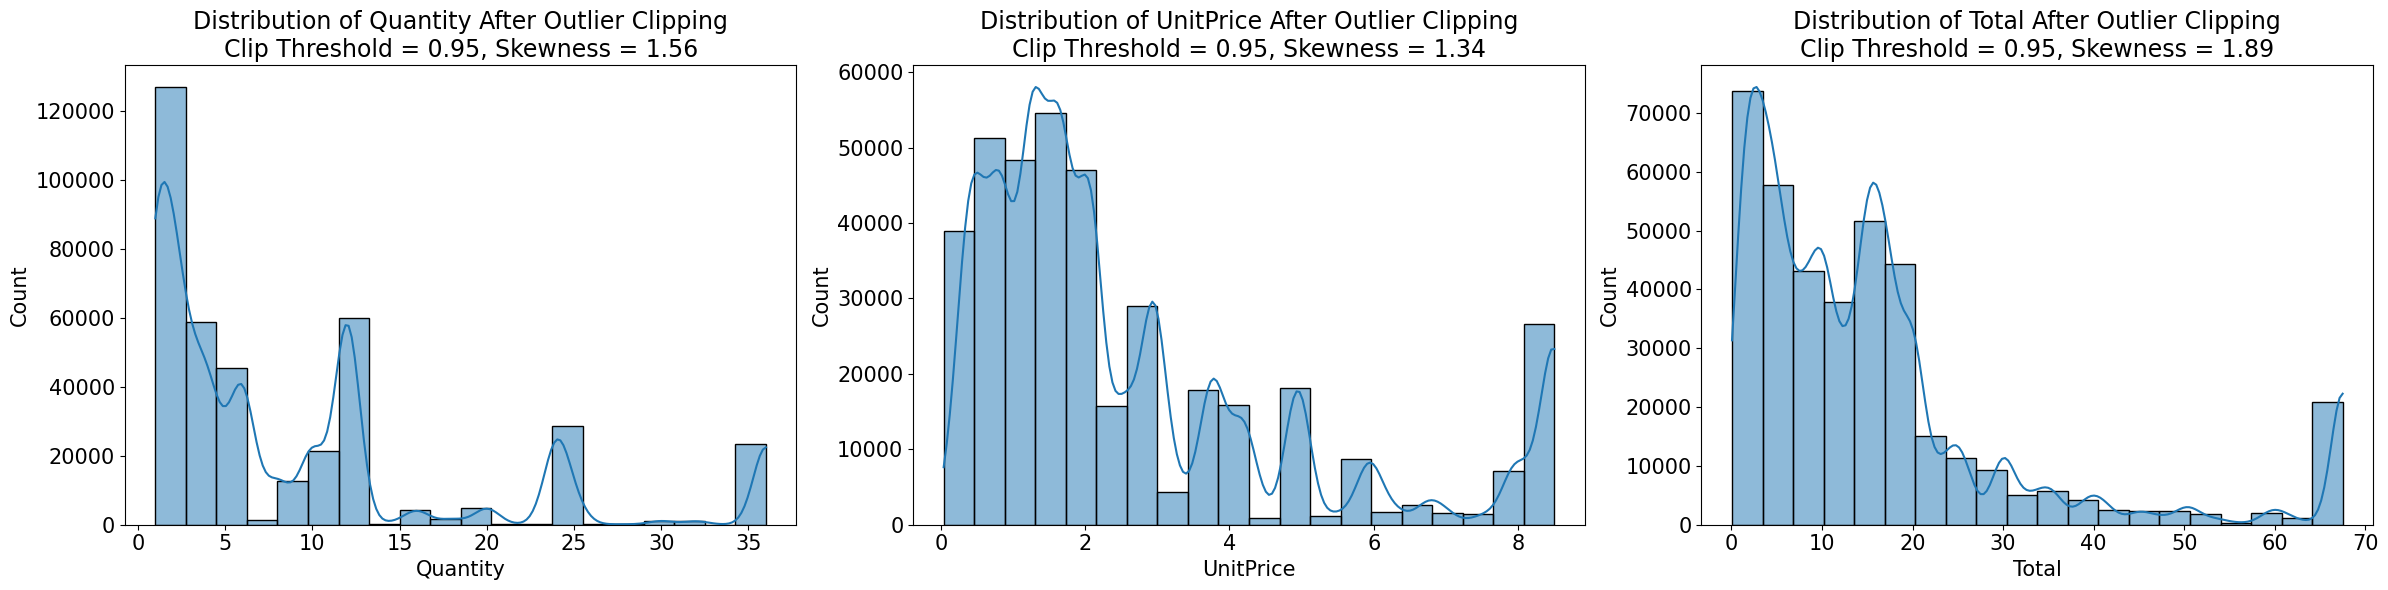

In [26]:
df_clipped = clip_outliers(0.95)
plot_histogram(df_clipped, "0.95")

In [27]:
#set clipped df as the main df
df = df_clipped.reset_index(drop=True)

In [28]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392688 entries, 0 to 392687
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392688 non-null  object        
 1   StockCode    392688 non-null  object        
 2   Description  392688 non-null  object        
 3   Quantity     392688 non-null  int64         
 4   InvoiceDate  392688 non-null  datetime64[ns]
 5   UnitPrice    392688 non-null  float64       
 6   CustomerID   392688 non-null  float64       
 7   Country      392688 non-null  object        
 8   Total        392688 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 27.0+ MB


In [30]:
df[["Quantity", "UnitPrice", "Total"]].describe()

,Quantity,UnitPrice,Total
count,392688.000000,392688.000000,392688.000000
mean,8.950653,2.675520,16.106067
std,9.544662,2.283675,16.337443
min,1.000000,0.040000,0.060000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,36.000000,8.500000,67.500000


##K-Means RFM Customer Segmentation

Perform customer segmentation with K-Means based on Recency, Frequency, Monetary Value (RFM) metrics

###RFM Metrics

In [31]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (df["InvoiceDate"].max() + pd.Timedelta(days=1) - x.max()).days,  # Recency (how many days since last purchase)
    'InvoiceNo': 'nunique',                                                                    # Frequency (how many purchases)
    'Total': 'sum'                                                                             # Monetary (total spent across purchases)
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [32]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,67.50
12347.0,2,7,3989.48
12348.0,75,4,1343.24
12349.0,19,1,1525.05
12350.0,310,1,334.40


In [33]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [34]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,1457.966637
std,100.014169,7.697998,3870.672416
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,276.607500
50%,51.000000,2.000000,618.340000
75%,142.000000,5.000000,1494.335000
max,374.000000,209.000000,124081.210000


###Standardization

In [35]:
scaler = StandardScaler()
scaled = scaler.fit_transform(rfm)
rfm_scaled = pd.DataFrame(scaled, columns=rfm.columns, index=rfm.index)

In [36]:
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,-0.359273
12347.0,-0.905340,0.354417,0.654100
12348.0,-0.175360,-0.035340,-0.029643
12349.0,-0.735345,-0.425097,0.017333
12350.0,2.174578,-0.425097,-0.290310


In [37]:
rfm_scaled.describe().map('{:.2f}'.format)

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-0.92,-0.43,-0.38
25%,-0.75,-0.43,-0.31
50%,-0.42,-0.30,-0.22
75%,0.49,0.09,0.01
max,2.81,26.60,31.68


###Optimal Cluster Count

Determine optimal K-Means cluster count(s) using Silhouette and Elbow methods

In [38]:
#calculate average silhouette scores and inertia scores for range of possible k values
k_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_scores = []
inertia_scores = []

for k in k_clusters:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    cluster_labels = kmeans.fit_predict(rfm_scaled)

    silhouette_avg = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    inertia_scores.append(kmeans.inertia_)

In [39]:
cluster_df = pd.DataFrame({
    'K': k_clusters,
    'Silhouette Score': silhouette_scores,
    'Inertia': inertia_scores})
cluster_df.set_index('K', inplace=True)
cluster_df

,Silhouette Score,Inertia
K,,
2,0.537010,9285.948356
3,0.567511,5492.063143
4,0.593111,4114.980580
5,0.590040,3002.545545
6,0.492764,2549.058620
7,0.495744,2081.402770
8,0.488254,1739.640206


In [40]:
#plots the set of scores for a given optimal cluster count method
def plot_method(scores, method, axes, ylabel):
  axes.plot(k_clusters, scores, color=CMAP_1, marker="o", markersize=8)
  axes.set_title('' + method + ' Method for Optimal k Clusters', fontsize=TITLE_FONT_SIZE)
  axes.set_xlabel('Number of Clusters (k)', fontsize=LABEL_TICK_FONT_SIZE)
  axes.set_ylabel(ylabel, fontsize=LABEL_TICK_FONT_SIZE)
  axes.set_xticks(k_clusters)
  axes.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE)

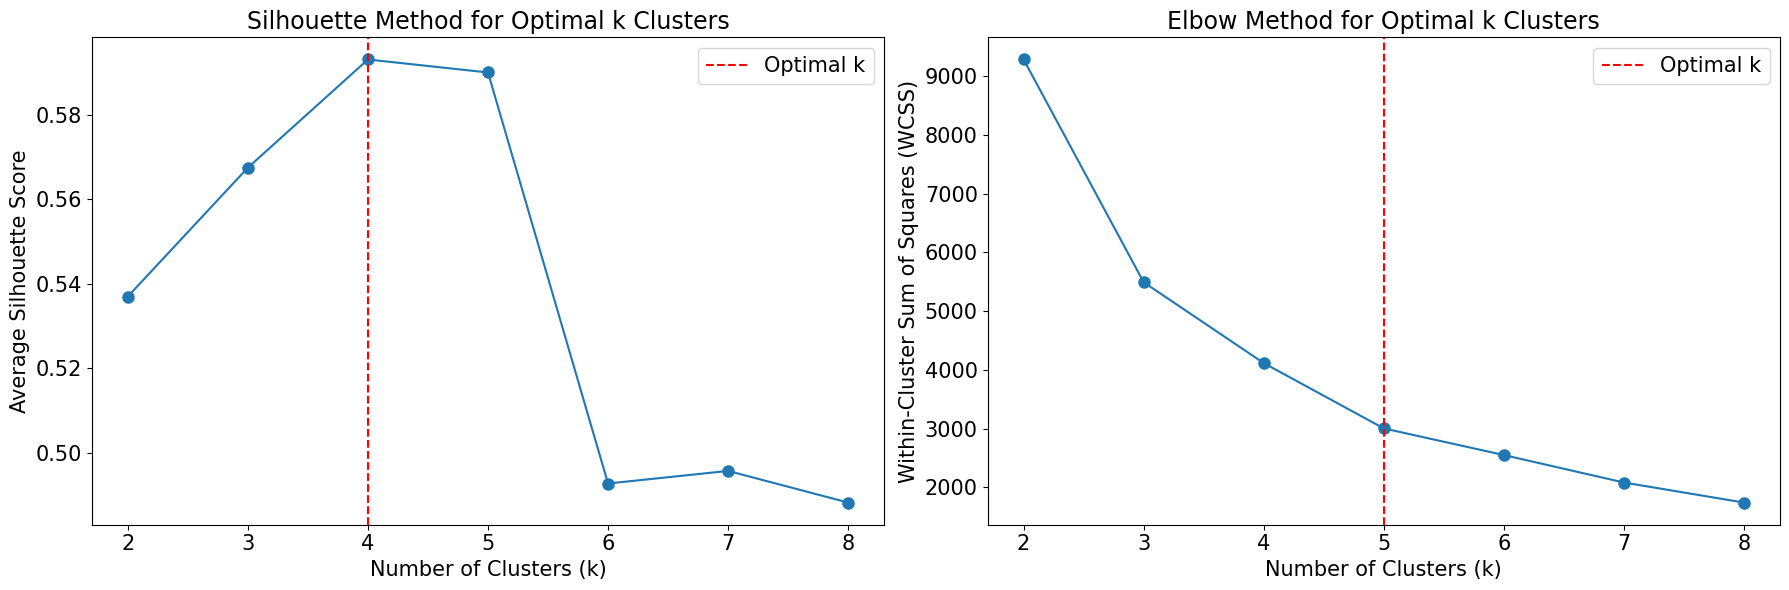

In [41]:
#plots average silhouette scores and inertia scores across k values
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_method(silhouette_scores, "Silhouette", axes[0], "Average Silhouette Score")
plot_method(inertia_scores, "Elbow", axes[1], "Within-Cluster Sum of Squares (WCSS)")

#mark optimal k's determined by silhouette method (max score) and elbow method (visual inspection)
axes[0].axvline(x=silhouette_scores.index(max(silhouette_scores))+2, color='r', linestyle='--', label='Optimal k')
axes[1].axvline(x=5, color='r', linestyle='--', label='Optimal k')

axes[0].legend(fontsize=LABEL_TICK_FONT_SIZE)
axes[1].legend(fontsize=LABEL_TICK_FONT_SIZE)
plt.tight_layout()
plt.show()

###K-Means Models

Perform 2 versions of K-Means clustering on the standardized RFM data, using k=4 and k=5 based on Silhouette and Elbow analysis

In [42]:
kmeans_4 = KMeans(n_clusters=4, random_state=RANDOM_STATE)
cluster_labels_4 = kmeans_4.fit_predict(rfm_scaled)

kmeans_5 = KMeans(n_clusters=5, random_state=RANDOM_STATE)
cluster_labels_5 = kmeans_5.fit_predict(rfm_scaled)

In [43]:
rfm['Cluster (k=4)'] = cluster_labels_4
rfm['Cluster (k=5)'] = cluster_labels_5
rfm.head()

,Recency,Frequency,Monetary,Cluster (k=4),Cluster (k=5)
CustomerID,,,,,
12346.0,326,1,67.50,1,1
12347.0,2,7,3989.48,0,0
12348.0,75,4,1343.24,0,0
12349.0,19,1,1525.05,0,0
12350.0,310,1,334.40,1,1


####3D Cluster Visualization

In [44]:
#plots a 3D scatterplot of the RFM clustering by a given k-means model, with labeled centroids
def plot_scatter_kmeans(kmeans, k, fig, pos, cmap):
  ax = fig.add_subplot(pos, projection='3d')
  non_scaled_centroids = scaler.inverse_transform(kmeans.cluster_centers_)       #un-standardize the centroids found by k-means
  ax.scatter(non_scaled_centroids[:, 0],
             non_scaled_centroids[:, 1],
             non_scaled_centroids[:, 2],
             s=600, c='red', alpha=1, label='Centroids')
  ax.scatter(rfm["Recency"], rfm["Frequency"], rfm["Monetary"],
             c=rfm["Cluster (k=" + k + ")"],
             cmap=cmap,
             s=90,
             alpha=1)
  ax.set_title('K-Means Clustering (k=' + k + ') of Customer RFM', fontsize=TITLE_FONT_SIZE+15)
  ax.set_xlabel('Recency', fontsize=LABEL_TICK_FONT_SIZE+8, labelpad=12)
  ax.set_ylabel('Frequency', fontsize=LABEL_TICK_FONT_SIZE+8, labelpad=12)
  ax.set_zlabel('Monetary', fontsize=LABEL_TICK_FONT_SIZE+8, labelpad=16)
  ax.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE+3)
  ax.legend(fontsize=LABEL_TICK_FONT_SIZE+5)
  ax.view_init(elev=15, azim=45)

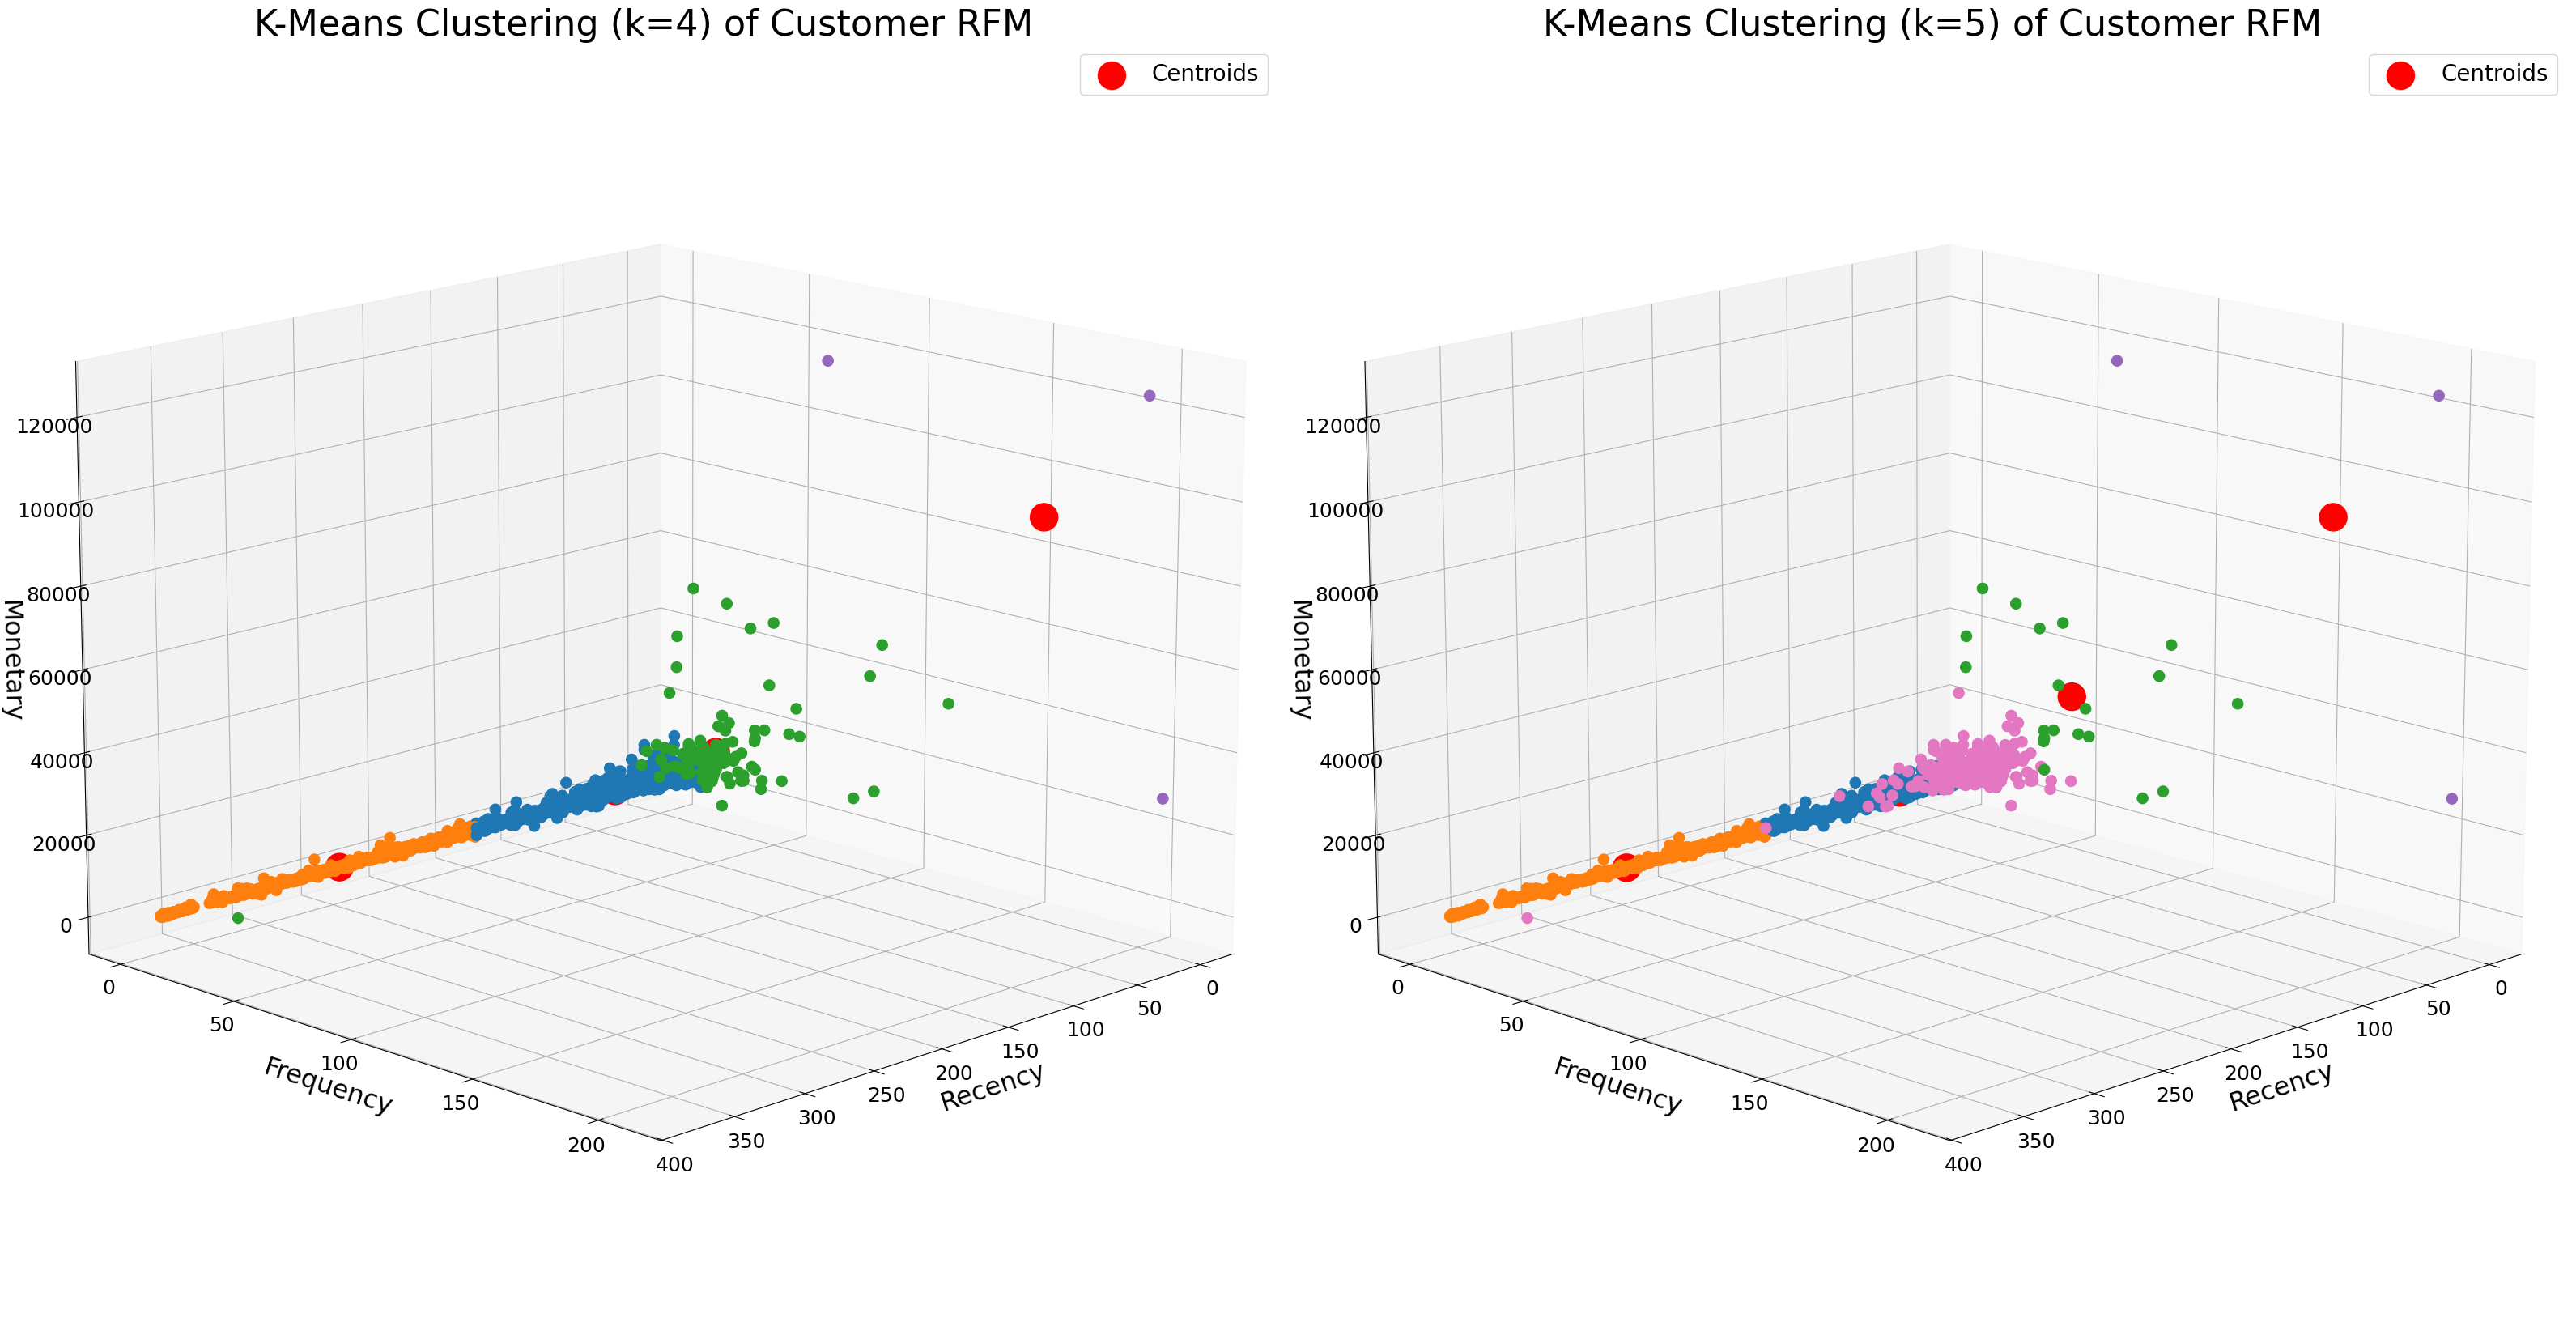

In [45]:
#plots cluster scatterplots for both k-means models
fig = plt.figure(figsize=(32, 16))

plot_scatter_kmeans(kmeans_4, "4", fig, 121, CMAP_4)
plot_scatter_kmeans(kmeans_5, "5", fig, 122, CMAP_5)

plt.tight_layout()
plt.show()

####2D t-SNE Cluster Visualization

In [46]:
#embed standardized RFM features to a 2D space using t-SNE
rfm_embedded = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=65, random_state=RANDOM_STATE).fit_transform(rfm_scaled.iloc[:, [0,1,2]])

In [47]:
#plots a 2D scatterplot of the RFM clustering by a given k-means model
def plot_scatter_tsne(k, axes, cmap):
  axes.scatter(rfm_embedded[:, 0], rfm_embedded[:, 1],
            c=rfm["Cluster (k=" + k + ")"],
            cmap=cmap,
            s=20)
  axes.set_xlabel('t-SNE Dimension 1', fontsize=LABEL_TICK_FONT_SIZE)
  axes.set_ylabel('t-SNE Dimension 2', fontsize=LABEL_TICK_FONT_SIZE)
  axes.set_title('K-Means Clustering (k=' + k + ') of Customer RFM\nt-SNE 2D Embedding', fontsize=TITLE_FONT_SIZE)
  axes.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE)

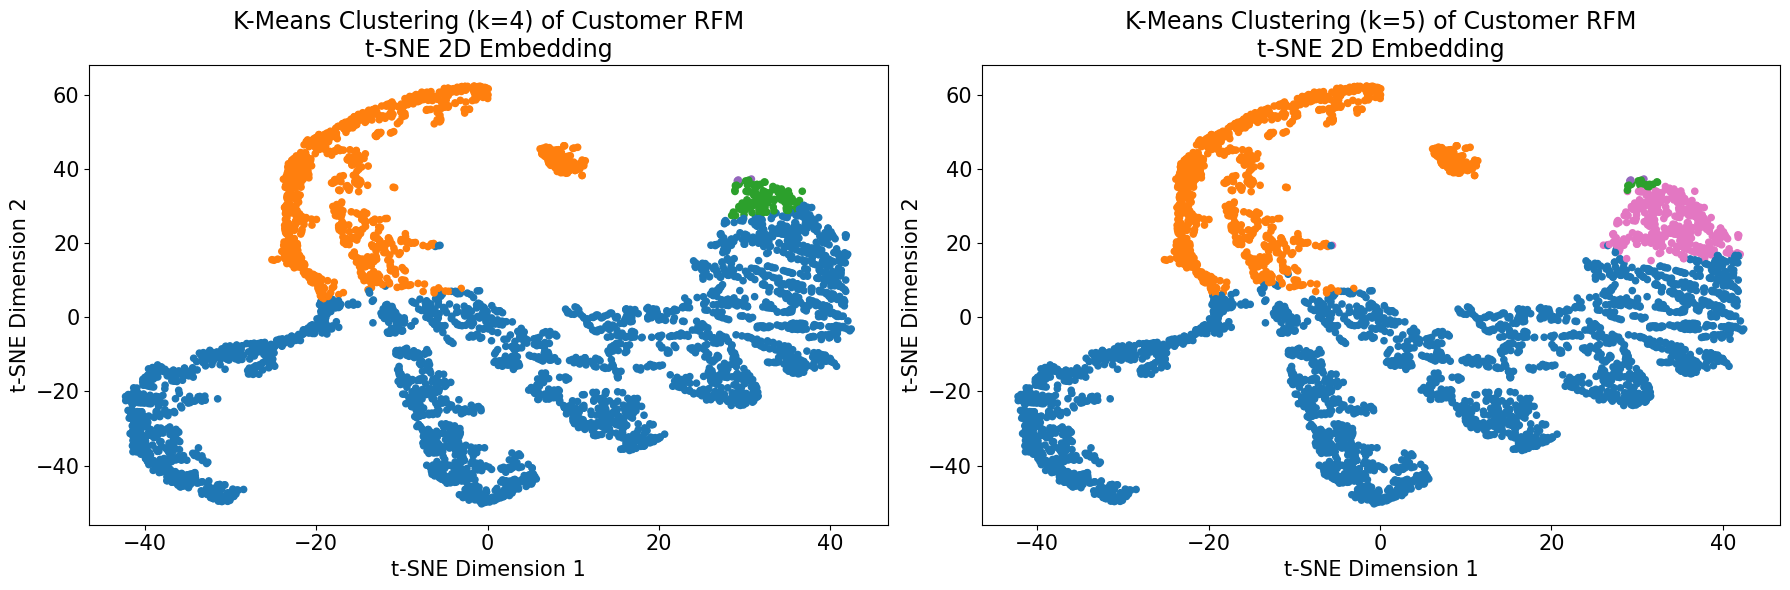

In [48]:
#plots embedded cluster scatterplots for both k-means models
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_scatter_tsne("4", axes[0], CMAP_4)
plot_scatter_tsne("5", axes[1], CMAP_5)

plt.tight_layout()
plt.show()

##Segmentation Business Analysis

Obtain insights based on the k=5 K-Means RFM Customer Segmentation model

Why k=5? Visual analysis indicates that k=5 preserves meaningful subgroups across the spectrum of customers in the low recency region

In [49]:
rfm_5 = rfm.copy()

#drop k=4 clusters
rfm_5.drop(columns=['Cluster (k=4)'], inplace=True)

#map cluster labels to [1-5] in ascending order of average Recency
cluster_rec_mean = rfm_5.groupby("Cluster (k=5)")["Recency"].mean()
sorted_clusters = cluster_rec_mean.sort_values().index
new_labels = {old: new for new, old in enumerate(sorted_clusters, start=1)}
rfm_5["Cluster (k=5)"] = rfm_5["Cluster (k=5)"].map(new_labels)

rfm_5.head()

,Recency,Frequency,Monetary,Cluster (k=5)
CustomerID,,,,
12346.0,326,1,67.50,5
12347.0,2,7,3989.48,4
12348.0,75,4,1343.24,4
12349.0,19,1,1525.05,4
12350.0,310,1,334.40,5


In [50]:
cluster_means = rfm_5.groupby('Cluster (k=5)').mean()
cluster_means

,Recency,Frequency,Monetary
Cluster (k=5),,,
1,1.333333,161.000000,89791.310000
2,7.800000,57.800000,30845.410500
3,14.976119,16.650746,5991.811701
4,45.257280,3.310723,1026.461292
5,248.953817,1.556079,409.877191


In [51]:
cluster_counts = rfm_5["Cluster (k=5)"].value_counts().sort_index()
cluster_counts

,count
Cluster (k=5),
1,3
2,20
3,335
4,2919
5,1061


In [52]:
cluster_summary = rfm_5.groupby('Cluster (k=5)').agg(['mean', 'median', 'min', 'max'])
cluster_summary

Recency                    Frequency                  \
                     mean median  min  max        mean median min  max   
Cluster (k=5)                                                            
1                1.333333    1.0    1    2  161.000000  201.0  73  209   
2                7.800000    4.0    1   39   57.800000   53.0  13  124   
3               14.976119    9.0    1  372   16.650746   15.0   5   55   
4               45.257280   35.0    1  156    3.310723    3.0   1   13   
5              248.953817  243.0  144  374    1.556079    1.0   1   12   

                   Monetary                                   
                       mean      median       min        max  
Cluster (k=5)                                                 
1              89791.310000  116411.440  28881.28  124081.21  
2              30845.410500   29637.625   9227.52   51964.98  
3               5991.811701    5184.710   1238.94   24972.63  
4               1026.461292     709.990      6.20    6550.41  
5                409.877191     285.330      3.75    6096.77

###Customer Profiles

Customer Profile | Recency | Frequency | Monetary | Cluster No. | Actions
---|---|---|---|--- | ---
🏆 Champions / VIPs | Very Low | Very High | Extremely High | 1 | Loyalty Rewards, Early Product Access, VIP Perks, Personalized Offers
🟢 Loyal Customers | Low | High | Very High | 2 | Loyalty Rewards, Upsell, Cross-Sell, Personalized Offers
🟡 Potential Loyalists | Moderate | Moderate | High | 3 | Targeted Promotions, Bundles, Recommendations, Nurturing Campaigns
🟠 At-Risk Customers | High | Low | Moderate | 4 | Discount Incentives, Win-Back Campaigns
🔴 Low-Value Customers | Very High | Very Low | Low | 5 | Broad Promotions, Re-Engagement Campaigns

In [53]:
#customer profile labels
label_map = {
    1:"Champions/VIPs",
    2:"Loyal Customers",
    3:"Potential Loyalists",
    4:"At-Risk Customers",
    5:"Low-Value Customers"
    }

###Heatmap

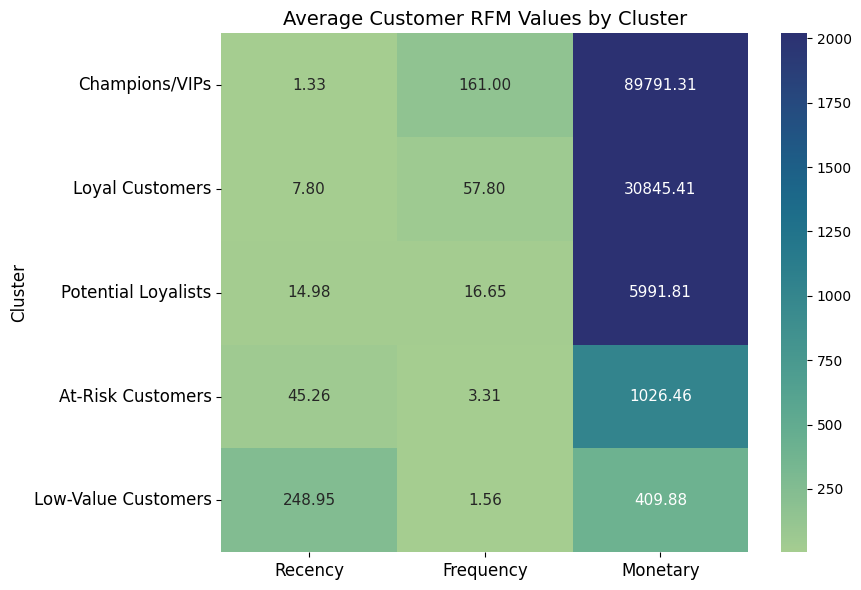

In [54]:
#plots a heatmap of the average RFM values for all 5 clusters

all_means = cluster_means.values.flatten()    #used to calculate heatmap gradient bounds

plt.figure(figsize=(9,6))
ax = sns.heatmap(cluster_means,
            annot=True, annot_kws={"fontsize": LABEL_TICK_FONT_SIZE-4},
            fmt=".2f",
            cmap="crest",
            vmin=np.percentile(all_means, 15), vmax=np.percentile(all_means, 80))

ax.set_title("Average Customer RFM Values by Cluster", fontsize=TITLE_FONT_SIZE-3)
ax.set_xlabel("", fontsize=LABEL_TICK_FONT_SIZE-3)
ax.set_ylabel("Cluster", fontsize=LABEL_TICK_FONT_SIZE-3)

#set y ticks to customer profile labels
ax.set_yticks([i + 0.5 for i in range(len(cluster_means.index))])
ax.set_yticklabels([f"{label_map[i]}" for i in cluster_means.index], rotation=0)

ax.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE-3)

plt.tight_layout()
plt.show()

###Bar Chart

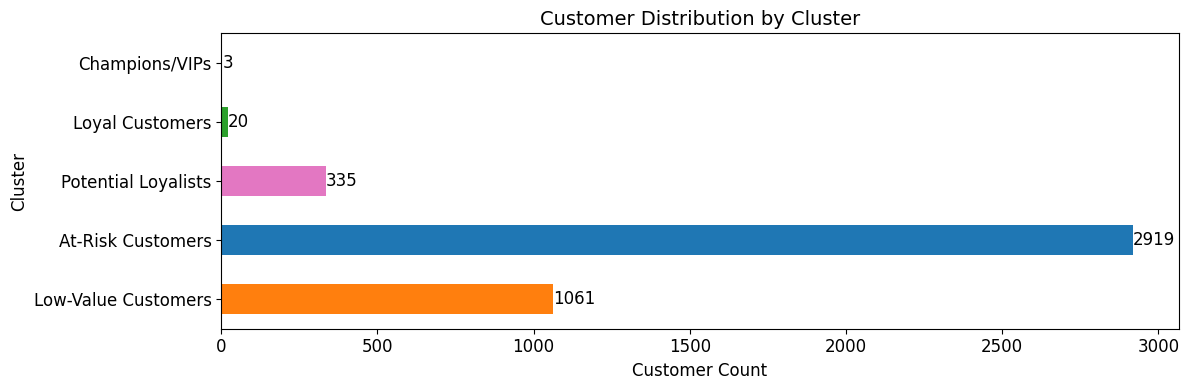

In [55]:
#plots a bar chart of the per-cluster customer distribution
plt.figure(figsize=(12,4))
ax = cluster_counts[::-1].plot(kind='barh', color=CMAP_5_PROFILES.colors[::-1])

for container in ax.containers:
    ax.bar_label(container, fontsize=LABEL_TICK_FONT_SIZE-3)    #count label for each bar

ax.set_ylabel('Cluster', fontsize=LABEL_TICK_FONT_SIZE-3)
ax.set_xlabel('Customer Count', fontsize=LABEL_TICK_FONT_SIZE-3)
ax.set_title('Customer Distribution by Cluster', fontsize=TITLE_FONT_SIZE-3)
ax.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE-3)

#set y ticks to customer profile labels
ax.set_yticklabels([f"{label_map[i]}" for i in cluster_counts.index[::-1]], rotation=0)

plt.tight_layout()
plt.show()

###Radar Chart

In [56]:
#scale cluster RFM means
mm_scaler = MinMaxScaler()
rfm_mm_scaled = mm_scaler.fit_transform(cluster_means)

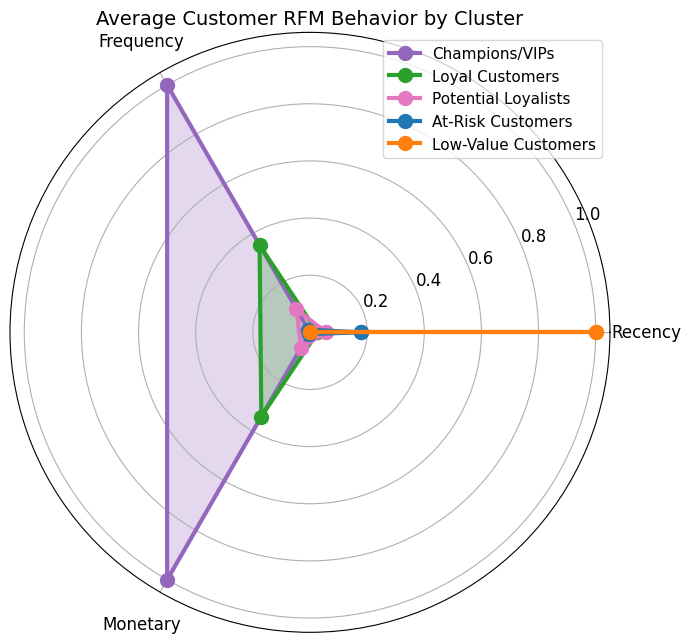

In [57]:
#plots a radar chart of the scaled average RFM values for all 5 clusters
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, polar=True)

labels = ["Recency","Frequency","Monetary"]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

for i, row in enumerate(rfm_mm_scaled):
    values = np.concatenate((row,[row[0]]))
    ax.plot(np.concatenate((angles,[angles[0]])),
            values,
            label=f"{label_map[i+1]}",  #set y ticks to customer profile labels
            marker='o',
            markersize=10,
            linewidth=3,
            color=CMAP_5_PROFILES.colors[i])
    ax.fill(np.concatenate((angles,[angles[0]])),
            values,
            color=CMAP_5_PROFILES.colors[i],
            alpha=0.25)

ax.set_thetagrids(angles * 180/np.pi, labels)
ax.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE-3)
ax.tick_params(axis='x', pad=16)

plt.legend(fontsize=LABEL_TICK_FONT_SIZE-4)
plt.title("Average Customer RFM Behavior by Cluster", fontsize=TITLE_FONT_SIZE-3)

plt.tight_layout()
plt.show()

###Bubble Plot

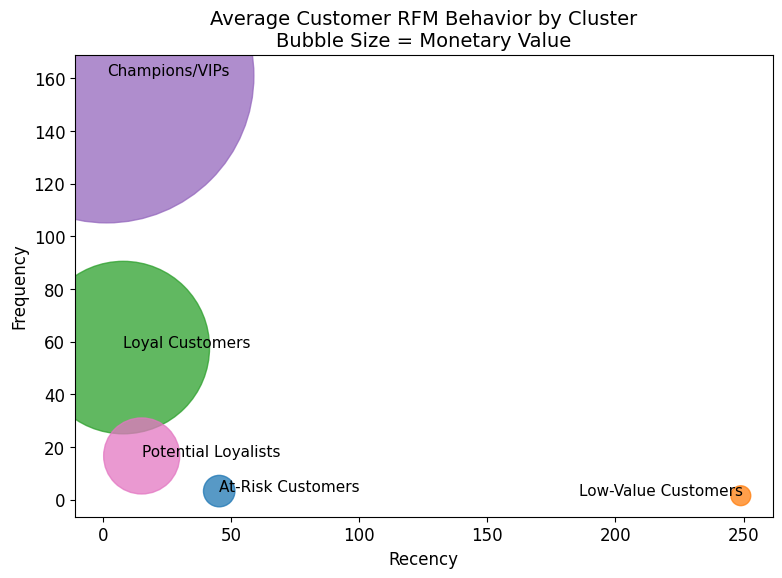

In [58]:
#plots a bubble plot of the average RFM values for all 5 clusters (bubble size = monetary)
plt.figure(figsize=(9,6))

ax = plt.scatter(
    cluster_means["Recency"],
    cluster_means["Frequency"],
    s=cluster_means["Monetary"]/2,
    c=CMAP_5_PROFILES.colors,
    alpha=0.75
)

dx = 0
for i in cluster_means.index:
  if (cluster_means["Recency"][i] > 200):   #prevent label overflow on the right side
    dx = -63                                #shift label to the left
  plt.text(
        cluster_means["Recency"][i]+dx,
        cluster_means["Frequency"][i],
        s=f"{label_map[i]}",                #set y ticks to customer profile labels
        fontsize=LABEL_TICK_FONT_SIZE-4
    )

plt.xlabel("Recency", fontsize=LABEL_TICK_FONT_SIZE-3)
plt.ylabel("Frequency", fontsize=LABEL_TICK_FONT_SIZE-3)
plt.tick_params(axis='both', labelsize=LABEL_TICK_FONT_SIZE-3)
plt.title("Average Customer RFM Behavior by Cluster\nBubble Size = Monetary Value", fontsize=TITLE_FONT_SIZE-3)
plt.show()